# EDA y Preparación de Series Temporales (LSTM) por Provincia
**Objetivo:** Predecir los picos de contagio semanales a nivel de Región y Provincia.
Realizaremos exploración de variables, tratamiento de nulos, análisis de correlación temporal y evaluación de la serie para su ingesta en una red LSTM.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')

# Cargamos tu extensión de nulos
%run '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/pandas_missing_extension.ipynb'

print("Entorno Global configurado.")

Entorno Global configurado.


## Paso 2: Análisis de Variables y Tratamiento de Nulos
Cargamos el dataset y usamos la extensión personalizada para evaluar la calidad del dato.
*Nota sobre duplicados:* No aplicaremos `drop_duplicates()`, ya que en vigilancia epidemiológica, múltiples registros idénticos representan pacientes distintos contagiados en las mismas circunstancias.

In [3]:
PATH_CSV = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/vigilancia_malaria_2009_2024.csv'
df = pd.read_csv(PATH_CSV, low_memory=False)
df.head(10)

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,TUMBES,ZARUMILLA,AGUAS VERDES,AGUAS VERDES,MALARIA POR P. VIVAX,2009,15,B51,24,240302,2403020001,32,A,M
1,ANCASH,CASMA,BUENA VISTA ALTA,HUANCHUY,MALARIA POR P. VIVAX,2009,18,B51,2,20802,0208020002,7,A,M
2,MADRE DE DIOS,MANU,MADRE DE DIOS,BOCA PUKIRI,MALARIA POR P. VIVAX,2009,19,B51,17,170203,1702030010,17,A,M
3,PIURA,SULLANA,SULLANA,HUANGALA,MALARIA POR P. VIVAX,2009,21,B51,31,200601,2006010023,53,A,F
4,ANCASH,YUNGAY,RANRAHIRCA,CAJAPAMPA,MALARIA POR P. VIVAX,2009,22,B51,2,22006,0220060006,24,A,M
5,ANCASH,CASMA,BUENA VISTA ALTA,TUCTUPILLIN,MALARIA POR P. VIVAX,2009,23,B51,2,20802,0208020006,18,A,M
6,ANCASH,CASMA,BUENA VISTA ALTA,TUCTUPILLIN,MALARIA POR P. VIVAX,2009,23,B51,2,20802,0208020006,7,A,M
7,ANCASH,CASMA,BUENA VISTA ALTA,TUCTUPILLIN,MALARIA POR P. VIVAX,2009,23,B51,2,20802,0208020006,9,A,M
8,LAMBAYEQUE,CHICLAYO,CHICLAYO,CHICLAYO,MALARIA POR P. VIVAX,2009,24,B51,14,140101,1401010001,48,A,F
9,ANCASH,SANTA,NUEVO CHIMBOTE,BUENOS AIRES,MALARIA POR P. VIVAX,2009,24,B51,2,21809,0218090001,35,A,F


In [4]:
df.dtypes

,0
departamento,object
provincia,object
distrito,object
localidad,object
enfermedad,object
ano,int64
semana,int64
diagnostic,object
diresa,int64
ubigeo,int64


In [5]:
df.missing.number_missing()

np.int64(24095)

Text(0.5, 1.0, 'Matriz de Nulos por Variable')

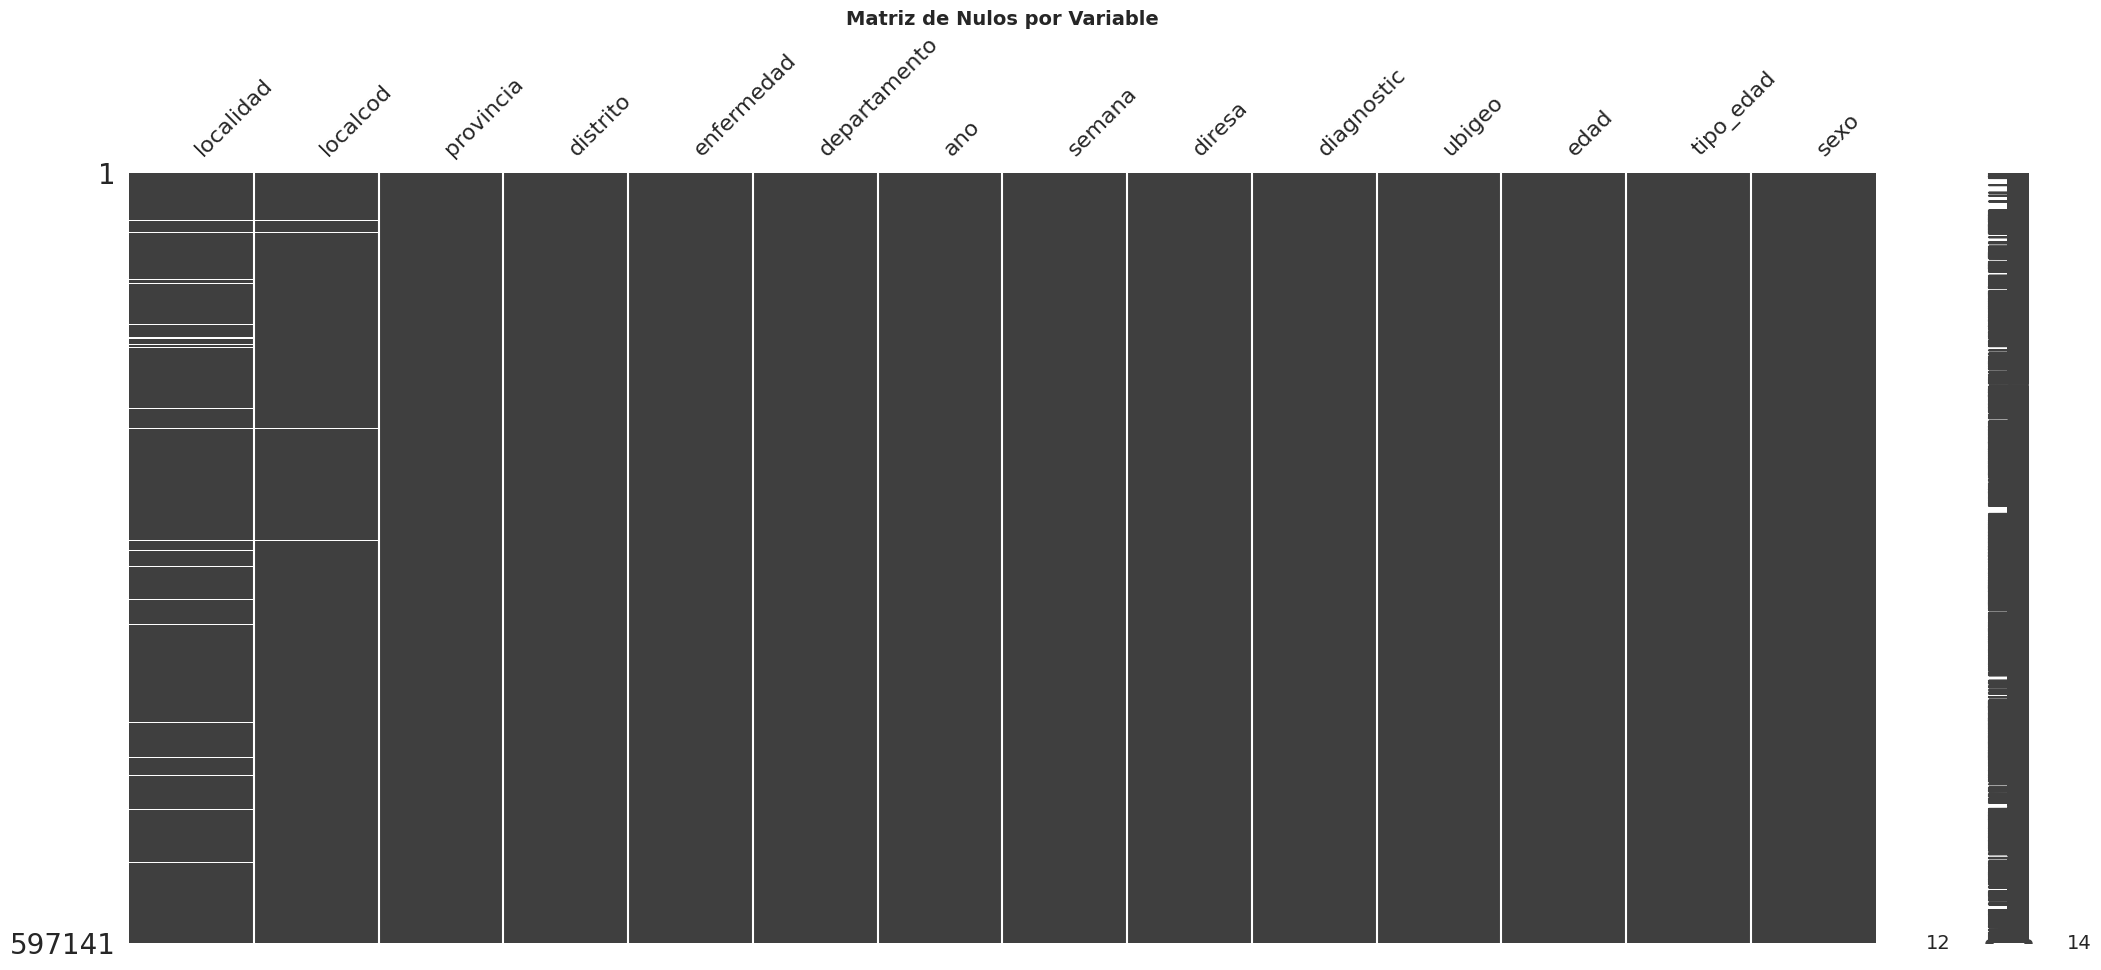

In [26]:
import missingno

# Matriz de visualización de nulos
ax = df.missing.sort_variables_by_missingness().pipe(missingno.matrix)
ax.set_title('Matriz de Nulos por Variable', fontsize=14, fontweight='bold')

In [6]:
# Limpieza estricta: Eliminamos filas donde falten datos clave para nuestra agrupación
df_clean = df.dropna(subset=['ano', 'semana', 'departamento', 'provincia'])

print(f"\nDimensiones finales tras limpieza: {df_clean.shape[0]} registros útiles.")


Dimensiones finales tras limpieza: 597141 registros útiles.


#PASO 3: AGRUPACIÓN POR REGIÓN (25 Departamentos)

In [7]:
df_region = df_clean.groupby(['departamento', 'ano', 'semana']).size().reset_index(name='total_casos')

In [8]:
df_region = df_region.sort_values(by=['departamento', 'ano', 'semana'])

In [9]:
print(f"Dataset agrupado por 25 regiones. Total de filas: {df_region.shape[0]}")
display(df_region.head())

Dataset agrupado por 25 regiones. Total de filas: 6400


,departamento,ano,semana,total_casos
0,AMAZONAS,2009,2,4
1,AMAZONAS,2009,3,5
2,AMAZONAS,2009,4,2
3,AMAZONAS,2009,5,2
4,AMAZONAS,2009,6,10


In [15]:
encoder = LabelEncoder()
df_region['id_region'] = encoder.fit_transform(df_region['departamento'])

## Creamos un diccionario para referencia futura en la App

In [17]:
mapa_regiones = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

In [18]:
print("Mapeo de Regiones completado:")
for depto, cod in list(mapa_regiones.items())[:5]: # Mostramos los primeros 5
    print(f"- {depto}: {cod}")

Mapeo de Regiones completado:
- AMAZONAS: 0
- ANCASH: 1
- APURIMAC: 2
- AREQUIPA: 3
- AYACUCHO: 4


In [20]:
print("\nVerificando nulos post-agrupación:")
df_region.missing.number_missing()


Verificando nulos post-agrupación:


np.int64(0)

#PASO 4: Visualización de Picos por Región

In [23]:
df_region['periodo_continuo'] = df_region['ano'] + (df_region['semana'] / 53.0)

Text(0, 0.5, 'Total de Casos')

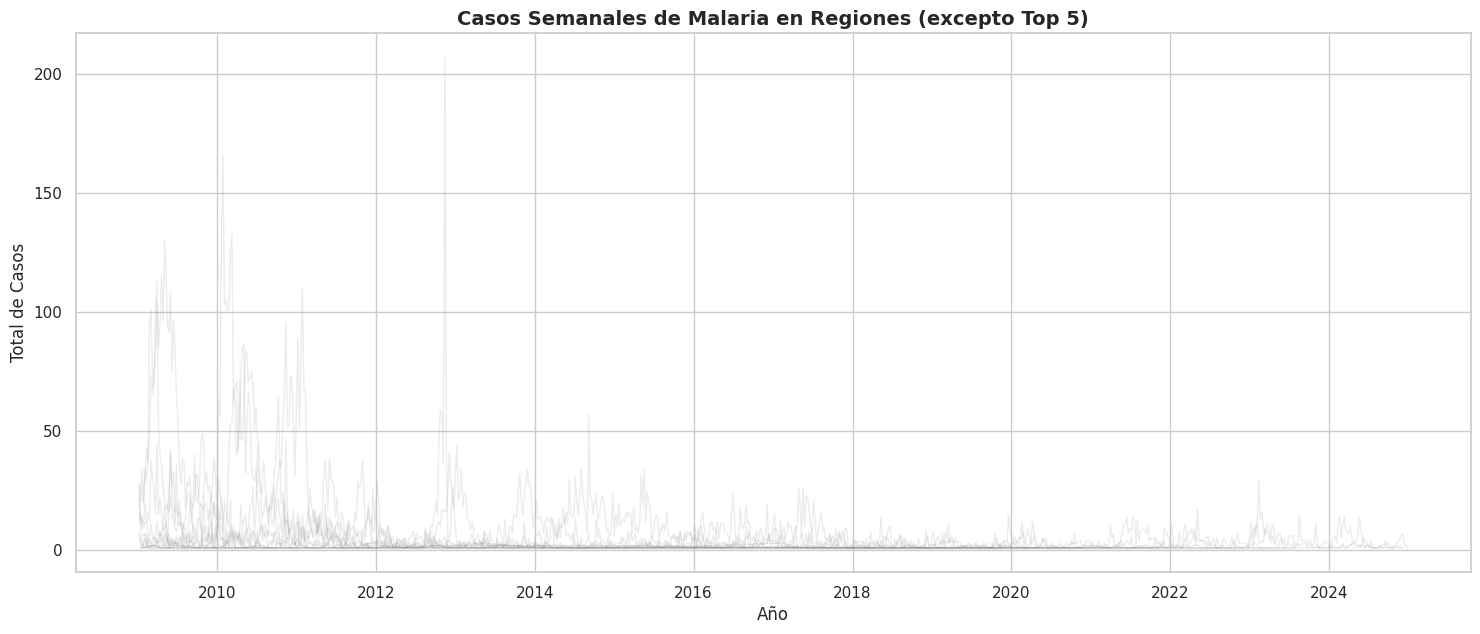

In [37]:
top_5_regiones = df_region.groupby('departamento')['total_casos'].sum().nlargest(5).index.tolist()
plt.figure(figsize=(18, 7))
# Trazamos TODAS las regiones en gris semitransparente (el "ruido" de fondo)
for depto in df_region['departamento'].unique():
    if depto not in top_5_regiones:
        subset = df_region[df_region['departamento'] == depto]
        plt.plot(subset['periodo_continuo'], subset['total_casos'], color='gray', alpha=0.15, linewidth=1)
plt.title('Casos Semanales de Malaria en Regiones (excepto Top 5)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Total de Casos')

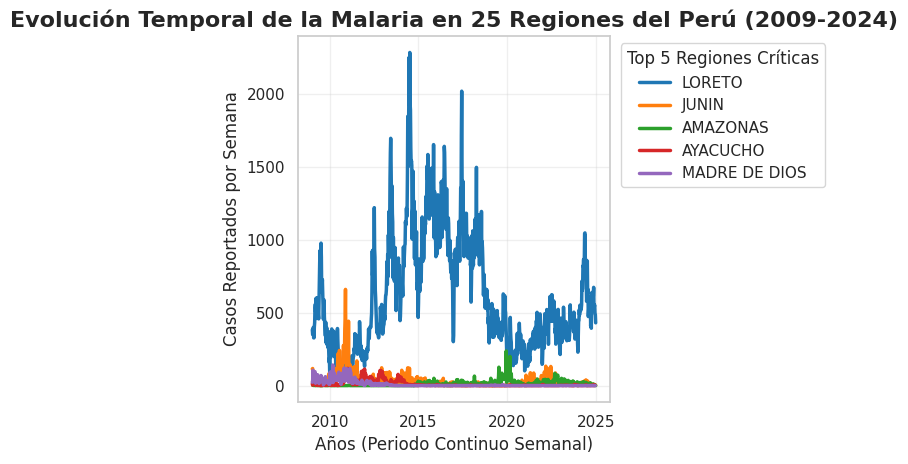

In [29]:
colores = sns.color_palette("tab10", len(top_5_regiones))
for idx, depto in enumerate(top_5_regiones):
    subset = df_region[df_region['departamento'] == depto]
    plt.plot(subset['periodo_continuo'], subset['total_casos'], color=colores[idx], label=depto, linewidth=2.5)
    plt.title('Evolución Temporal de la Malaria en 25 Regiones del Perú (2009-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Años (Periodo Continuo Semanal)')
plt.ylabel('Casos Reportados por Semana')
plt.legend(title='Top 5 Regiones Críticas', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Paso 5: Filtro solo por region LORETO

In [40]:
df_loreto = df_clean[df_clean['departamento'] == 'LORETO']

In [41]:
df_provincias = df_loreto.groupby(['provincia', 'ano', 'semana']).size().reset_index(name='total_casos')

In [42]:
df_provincias = df_provincias.sort_values(by=['provincia', 'ano', 'semana'])

In [43]:
print(f"Dataset reducido a LORETO: {df_provincias.shape[0]} semanas epidemiológicas útiles.")
display(df_provincias.head())

Dataset reducido a LORETO: 5830 semanas epidemiológicas útiles.


,provincia,ano,semana,total_casos
0,ALTO AMAZONAS,2009,1,46
1,ALTO AMAZONAS,2009,2,64
2,ALTO AMAZONAS,2009,3,84
3,ALTO AMAZONAS,2009,4,83
4,ALTO AMAZONAS,2009,5,64


##MATRIZ DE CORRELACIÓN TEMPORAL (AUTO-CORRELACIÓN)

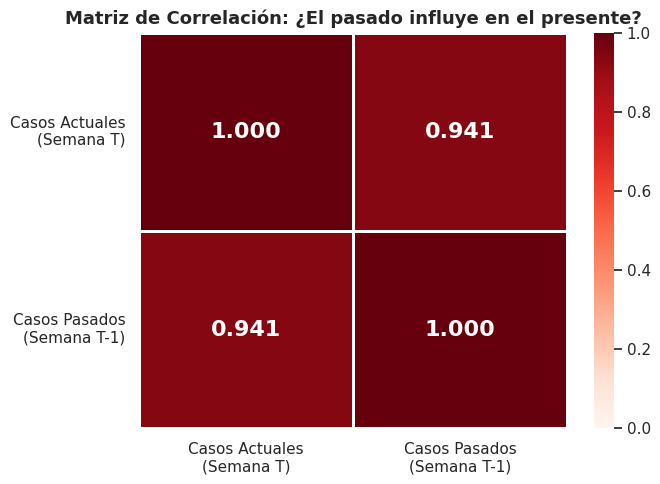

In [51]:
# 1. Creamos el "Lag"
# IMPORTANTE: Agrupamos por provincia para que la red no mezcle
# la última semana de Maynas con la primera semana de Putumayo.
df_provincias['casos_semana_pasada'] = df_provincias.groupby('provincia')['total_casos'].shift(1)

# 2. Limpieza rápida (La primera semana de la historia no tiene "semana pasada", sale NaN)
df_provincias = df_provincias.fillna(0)

# 3. Calculamos la matriz de correlación de Pearson
columnas_corr = ['total_casos', 'casos_semana_pasada']
matriz_corr = df_provincias[columnas_corr].corr()

# 4. Graficamos el Mapa de Calor
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap='Reds', vmin=0, vmax=1,
            fmt=".3f", linewidths=1, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Matriz de Correlación: ¿El pasado influye en el presente?', fontsize=13, fontweight='bold')
plt.xticks(ticks=[0.5, 1.5], labels=['Casos Actuales\n(Semana T)', 'Casos Pasados\n(Semana T-1)'], fontsize=11)
plt.yticks(ticks=[0.5, 1.5], labels=['Casos Actuales\n(Semana T)', 'Casos Pasados\n(Semana T-1)'], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

In [44]:
df_provincias['periodo'] = df_provincias['ano'] + (df_provincias['semana'] / 53.0)

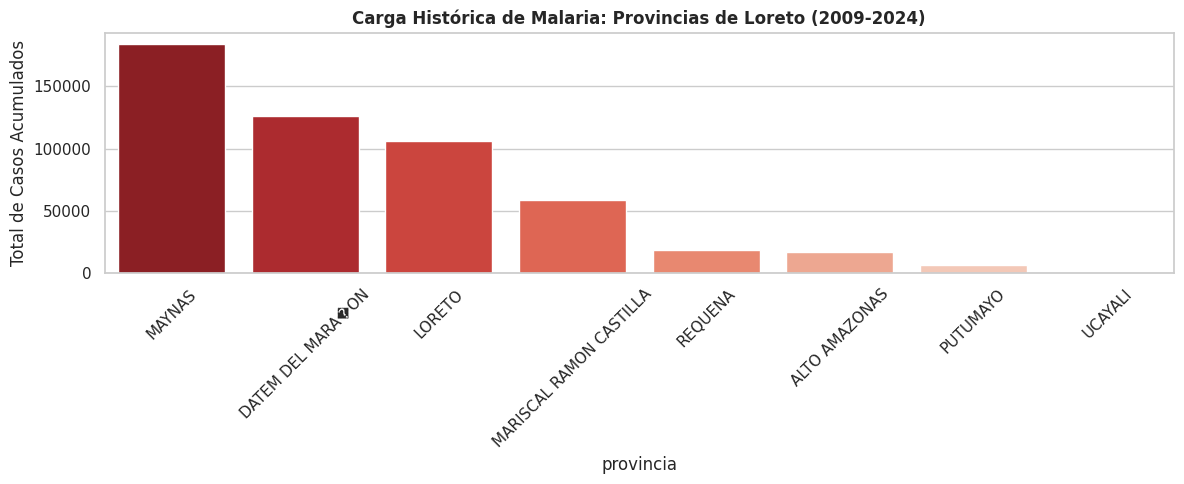

In [45]:
# 1. BARRAS: Carga Histórica por Provincia
plt.figure(figsize=(12, 5))
carga_prov = df_provincias.groupby('provincia')['total_casos'].sum().sort_values(ascending=False)
sns.barplot(x=carga_prov.index, y=carga_prov.values, palette='Reds_r')
plt.title('Carga Histórica de Malaria: Provincias de Loreto (2009-2024)', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total de Casos Acumulados')
plt.tight_layout()
plt.show()

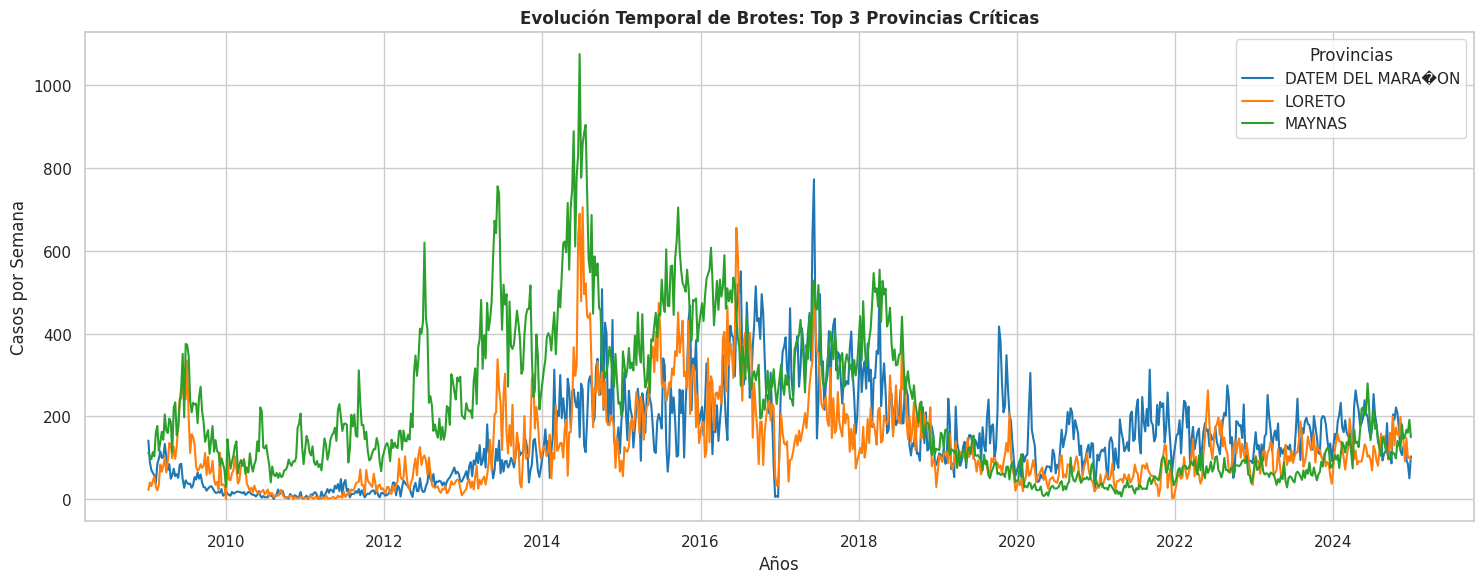

In [47]:
# 2. LÍNEA DE TIEMPO: Las 3 provincias más críticas
top_3 = carga_prov.head(3).index
df_top3 = df_provincias[df_provincias['provincia'].isin(top_3)]
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_top3, x='periodo', y='total_casos', hue='provincia', palette='tab10', linewidth=1.5)
plt.title('Evolución Temporal de Brotes: Top 3 Provincias Críticas', fontweight='bold')
plt.xlabel('Años')
plt.ylabel('Casos por Semana')
plt.legend(title='Provincias')
plt.tight_layout()
plt.show()

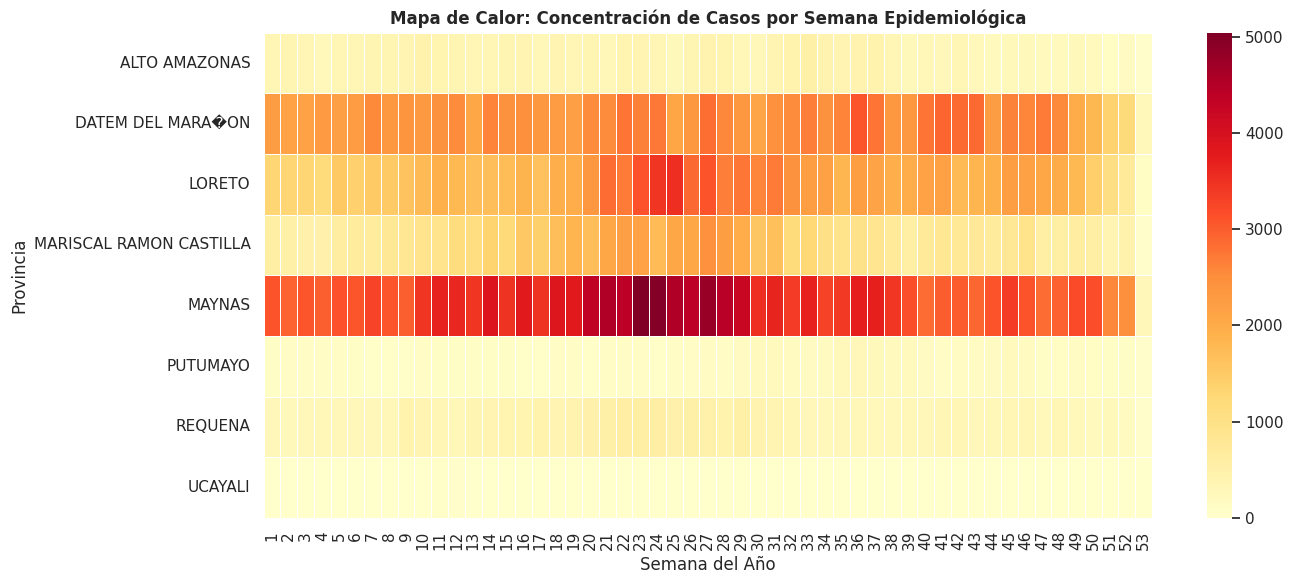

In [48]:
# 3. MAPA DE CALOR: Estacionalidad Loretana (Semana vs Provincia)
plt.figure(figsize=(14, 6))
pivot_loreto = df_provincias.groupby(['provincia', 'semana'])['total_casos'].sum().unstack().fillna(0)
sns.heatmap(pivot_loreto, cmap='YlOrRd', linewidths=0.5)
plt.title('Mapa de Calor: Concentración de Casos por Semana Epidemiológica', fontweight='bold')
plt.xlabel('Semana del Año')
plt.ylabel('Provincia')
plt.tight_layout()
plt.show()

## Paso 6: Exportación del Dataset Preparado

In [49]:
PATH_OUTPUT = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/dataset_loreto_provincias.csv'

df_provincias.to_csv(PATH_OUTPUT, index=False)

print(f"✅ EDA Completado.")
print(f"✅ Archivo listo para la Red Neuronal: {PATH_OUTPUT}")

✅ EDA Completado.
✅ Archivo listo para la Red Neuronal: /content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/dataset_loreto_provincias.csv
